In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/manjitbaishya2026/nrc-vad/NRC-VAD-Lexicon-v2.1.txt
/kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/activations_pooled.pkl
/kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/__results__.html
/kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/__notebook__.ipynb
/kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/__output__.json
/kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/custom.css
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__results__.html
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__huggingface_repos__.json
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__notebook__.ipynb
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/__output__.json
/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction/custom.css
/kaggle/input/notebooks/bencarson/gemma-4-functional-em

In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [3]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
import os, glob

PHASE2_PKL_CANDIDATES = [
    # Kaggle slug derived from notebook title "Gemma 4 Emotions Phase 2"
    "/kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/activations_pooled.pkl",
    # Fallback slugs in case title differs
    "/kaggle/input/notebooks/bencarson/gemma-4-phase2-pooled-extraction/activations_pooled.pkl",
    "/kaggle/input/gemma-4-emotions-phase-2/activations_pooled.pkl",
    "/kaggle/input/gemma-4-phase2-pooled-extraction/activations_pooled.pkl",
    "/kaggle/working/activations_pooled.pkl",
]
PHASE1_PKL = (
    "/kaggle/input/notebooks/bencarson/gemma-4-functional-emotions-vector-extraction"
    "/emotions_phase1/activations.pkl"
)
NRC_PATH = "/kaggle/input/datasets/manjitbaishya2026/nrc-vad/NRC-VAD-Lexicon-v2.1.txt"

# Layer 18 is optimal by Phase 2 layer sweep (|valence_r|=0.758 vs 0.617 at layer 25)
LAYER = 18

# Auto-detect: try known paths, then glob for any activations_pooled.pkl in /kaggle/input
ACTS_PATH = next((p for p in PHASE2_PKL_CANDIDATES if os.path.exists(p)), None)
if ACTS_PATH is None:
    hits = glob.glob("/kaggle/input/**/activations_pooled.pkl", recursive=True)
    ACTS_PATH = hits[0] if hits else PHASE1_PKL

print(f"Loading activations from: {ACTS_PATH}")
print(f"Analysis layer: {LAYER}")

with open(ACTS_PATH, "rb") as f:
    saved = pickle.load(f)

resid_acts = saved["resid"]  # {emotion: [n_stories, n_layers, d_model]}
meta = saved.get("meta", {})
if meta:
    print(f"  extraction={meta.get('extraction')}  "
          f"pool_start={meta.get('emotion_pool_start')}  "
          f"n_neutral={meta.get('n_neutral')}")

nrc = pd.read_csv(NRC_PATH, sep="\t", header=0,
                  names=["word", "valence", "arousal", "dominance"])
nrc = nrc.drop_duplicates("word").set_index("word")


Loading activations from: /kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/activations_pooled.pkl
Analysis layer: 18
  extraction=mean_pool  pool_start=50  n_neutral=100


In [4]:
# ── Cell 3: Compute mean directions at layer 25 ──────────────────────────────
# Centering: Tim Duffy's approach — subtract the global mean of all emotion
# means rather than an external neutral baseline. Neutral stories are reserved
# solely for PCA denoising (Cell 4b). This keeps direction geometry entirely
# within the emotion subspace.

neutral_stories = resid_acts["__neutral__"]        # [n_neutral, n_layers, d_model]
n_neutral = neutral_stories.shape[0]

# Compute per-emotion means at the analysis layer
emotion_names, emotion_means = [], []
for name, arr in resid_acts.items():
    if name == "__neutral__":
        continue
    emotion_means.append(arr[:, LAYER, :].mean(axis=0))  # [d_model]
    emotion_names.append(name)

emotion_means = np.stack(emotion_means)  # [n_emotions, d_model]

# Global mean (mean of all emotion means — Tim's approach)
global_mean = emotion_means.mean(axis=0)  # [d_model]

# Neutral mean (for reference / comparison with old approach)
neutral_mean = neutral_stories[:, LAYER, :].mean(axis=0)  # [d_model]

# Emotion directions = mean - global_mean
directions = emotion_means - global_mean  # [n_emotions, d_model]

print(f"Direction matrix: {directions.shape}")
print(f"Neutral stories:  {n_neutral}")
print(f"Centering: global mean of {len(emotion_names)} emotion means")


Direction matrix: (174, 1536)
Neutral stories:  100
Centering: global mean of 174 emotion means


In [5]:
# ── Cell 4: Match to NRC-VAD ─────────────────────────────────────────────────
def lookup_vad(name):
    word = name.replace('_', ' ').lower()
    if word in nrc.index:
        return nrc.loc[word, ['valence', 'arousal', 'dominance']].values.astype(float)
    first = word.split()[0]
    if first in nrc.index:
        return nrc.loc[first, ['valence', 'arousal', 'dominance']].values.astype(float)
    return None

vad_rows, kept_names, kept_dirs, missing = [], [], [], []
for name, direction in zip(emotion_names, directions):
    row = lookup_vad(name)
    if row is not None:
        vad_rows.append(row)
        kept_names.append(name)
        kept_dirs.append(direction)
    else:
        missing.append(name)

if missing:
    print(f"No NRC entry for: {missing}")

vad  = np.array(vad_rows)   # [N, 3]  — valence, arousal, dominance
dirs = np.array(kept_dirs)  # [N, 1536]
print(f"Matched {len(kept_names)}/{len(emotion_names)} emotions")


No NRC entry for: ['energized', 'insulted', 'stimulated']
Matched 171/174 emotions


In [6]:
# ── Cell 4b: Neutral-subspace denoising + comparison PCA ─────────────────────
# Projects out the top-k PCs of neutral activations from emotion directions.
# Neutral stories come from resid_acts['__neutral__']:
#   Phase 2 pkl → 100 mean-pooled neutral stories  (preferred)
#   Phase 1 pkl → 10 last-token neutral stories    (fallback)
#
# The denoising isolates emotion-specific variance by removing directions that
# are active even during emotionally-neutral processing.

VARIANCE_THRESHOLD = 0.50

neutral_raw_all = neutral_stories[:, LAYER, :]  # [n_neutral, d_model]
print(f"Neutral activations for denoising: {neutral_raw_all.shape}")

# Fit PCA on neutral activations
pca_neutral = PCA()
pca_neutral.fit(neutral_raw_all)
cumvar_n = np.cumsum(pca_neutral.explained_variance_ratio_)
n_n_pcs  = int(np.searchsorted(cumvar_n, VARIANCE_THRESHOLD) + 1)
print(f"\nNeutral PCA: {n_n_pcs} PC(s) → {cumvar_n[n_n_pcs-1]*100:.1f}% of neutral variance")
for i in range(n_n_pcs):
    print(f"  PC{i+1}: {pca_neutral.explained_variance_ratio_[i]*100:.1f}%")

neutral_comps = pca_neutral.components_[:n_n_pcs]  # [k, d_model]

def denoise_vec(vec, comps):
    return vec - comps.T @ (comps @ vec)

dirs_denoised = np.array([denoise_vec(d, neutral_comps) for d in dirs])
print(f"\nDirs: {dirs.shape} → denoised: {dirs_denoised.shape}")

# Comparison table: raw vs denoised
def show_pca_table(D, vad_arr, label, n_show=10):
    pca_t    = PCA(n_components=min(n_show, len(D)))
    scores_t = pca_t.fit_transform(D)
    print(f"\n── {label} ──")
    print(f"{'PC':>4}  {'var%':>6}  {'valence_r':>12}  {'arousal_r':>10}  {'dominance_r':>12}")
    for i in range(pca_t.n_components_):
        rv, pv = stats.pearsonr(scores_t[:, i], vad_arr[:, 0])
        ra, _  = stats.pearsonr(scores_t[:, i], vad_arr[:, 1])
        rd, _  = stats.pearsonr(scores_t[:, i], vad_arr[:, 2])
        sig = "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else "  "))
        print(f"{i+1:>4}  {pca_t.explained_variance_ratio_[i]*100:>5.1f}%"
              f"  {rv:>+10.3f}{sig:<3s}  {ra:>+10.3f}  {rd:>+12.3f}")
    return pca_t, scores_t

pca_raw, scores_raw = show_pca_table(dirs,          vad, "Raw  (global-mean centred)")
pca_den, scores_den = show_pca_table(dirs_denoised, vad,
                                     f"Denoised  ({n_n_pcs}-PC neutral subspace projected out, n={len(neutral_raw_all)})")


Neutral activations for denoising: (100, 1536)

Neutral PCA: 10 PC(s) → 50.6% of neutral variance
  PC1: 10.0%
  PC2: 8.6%
  PC3: 7.0%
  PC4: 5.6%
  PC5: 4.5%
  PC6: 3.7%
  PC7: 3.4%
  PC8: 2.9%
  PC9: 2.5%
  PC10: 2.3%

Dirs: (171, 1536) → denoised: (171, 1536)

── Raw  (global-mean centred) ──
  PC    var%     valence_r   arousal_r   dominance_r
   1   14.6%      -0.758***      +0.185        -0.591
   2    7.4%      -0.063         -0.283        -0.203
   3    5.6%      +0.057         -0.382        -0.236
   4    5.1%      +0.243**       +0.357        +0.290
   5    4.5%      +0.032         -0.023        -0.009
   6    4.0%      +0.063         -0.064        +0.140
   7    3.6%      -0.127         -0.089        +0.020
   8    3.0%      +0.092         -0.199        -0.063
   9    2.9%      -0.040         -0.168        -0.158
  10    2.6%      -0.053         +0.071        +0.035

── Denoised  (10-PC neutral subspace projected out, n=100) ──
  PC    var%     valence_r   arousal_r   domina

In [7]:
# ── Cell 5: PCA ──────────────────────────────────────────────────────────────
N_PCS = 50
pca    = PCA(n_components=N_PCS)
scores = pca.fit_transform(dirs_denoised)  # [N, 50]

cumvar = np.cumsum(pca.explained_variance_ratio_)
for k in [3, 5, 10, 16, 20, 36]:
    if k <= N_PCS:
        print(f"  {k:2d} PCs → {cumvar[k-1]*100:.1f}% variance")


   3 PCs → 27.6% variance
   5 PCs → 37.2% variance
  10 PCs → 53.1% variance
  16 PCs → 64.4% variance
  20 PCs → 69.5% variance
  36 PCs → 81.7% variance


In [8]:
# ── Cell 6: Per-PC correlation table — V, A, D ───────────────────────────────
dim_names = ['valence', 'arousal', 'dominance']
N_SHOW    = 20
rows = []
for i in range(N_SHOW):
    row = {'PC': i+1, 'var%': f"{pca.explained_variance_ratio_[i]*100:.1f}"}
    for j, dim in enumerate(dim_names):
        r, p = stats.pearsonr(scores[:, i], vad[:, j])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        row[f'{dim}_r'] = f"{r:+.3f}{sig}"
    rows.append(row)

print(pd.DataFrame(rows).set_index('PC').to_string())

    var%  valence_r  arousal_r dominance_r
PC                                        
1   14.6  +0.760***    -0.184*   +0.592***
2    7.4     -0.055  -0.288***    -0.202**
3    5.6     +0.033  -0.402***   -0.260***
4    5.0   +0.234**  +0.335***   +0.262***
5    4.5     -0.054     -0.013      -0.006
6    3.9     +0.088     -0.040     +0.158*
7    3.6     -0.124     -0.091      +0.023
8    3.0     +0.090   -0.205**      -0.064
9    2.9     -0.037    -0.169*     -0.154*
10   2.5     -0.063     +0.063      +0.021
11   2.3     -0.134     +0.046      -0.118
12   2.1     +0.028     +0.072      +0.069
13   2.0     -0.008     -0.066      +0.144
14   1.7     +0.019     +0.123      +0.126
15   1.6     +0.021     -0.082     -0.163*
16   1.5     +0.118     -0.093      +0.002
17   1.5     +0.083     -0.076      -0.053
18   1.3     -0.045     +0.117      -0.033
19   1.3     -0.048     +0.005      -0.017
20   1.1     +0.109     +0.077      +0.113


 Lay    type  PC1var%   PC1 val_r   PC1 aro_r    BestVal    BestAro  nNPCs
   0   local    18.2%      -0.363      +0.213  PC2 r=0.610  PC8 r=0.372      9
   1   local    15.4%      +0.434      -0.178  PC2 r=0.523  PC7 r=0.261      8
   2   local    15.9%      +0.358      -0.195  PC2 r=0.620  PC7 r=0.301     10
   3   local    15.9%      +0.429      -0.180  PC2 r=0.486  PC7 r=0.208      9
   4  GLOBAL    14.8%      +0.606      -0.216  PC1 r=0.606  PC7 r=0.409     15
   5   local    15.3%      +0.588      -0.200  PC1 r=0.588  PC6 r=0.477     15
   6   local    16.0%      +0.688      -0.208  PC1 r=0.688  PC5 r=0.405     14
   7   local    15.7%      +0.714      -0.176  PC1 r=0.714  PC5 r=0.391     12
   8   local    16.4%      +0.777      -0.144  PC1 r=0.777  PC3 r=0.384     12
   9  GLOBAL    11.5%      -0.734      +0.138  PC1 r=0.734  PC4 r=0.395     12
  10   local    11.4%      +0.711      -0.111  PC1 r=0.711  PC7 r=0.301     11
  11   local     9.9%      +0.679      -0.092  PC1 r=0.6

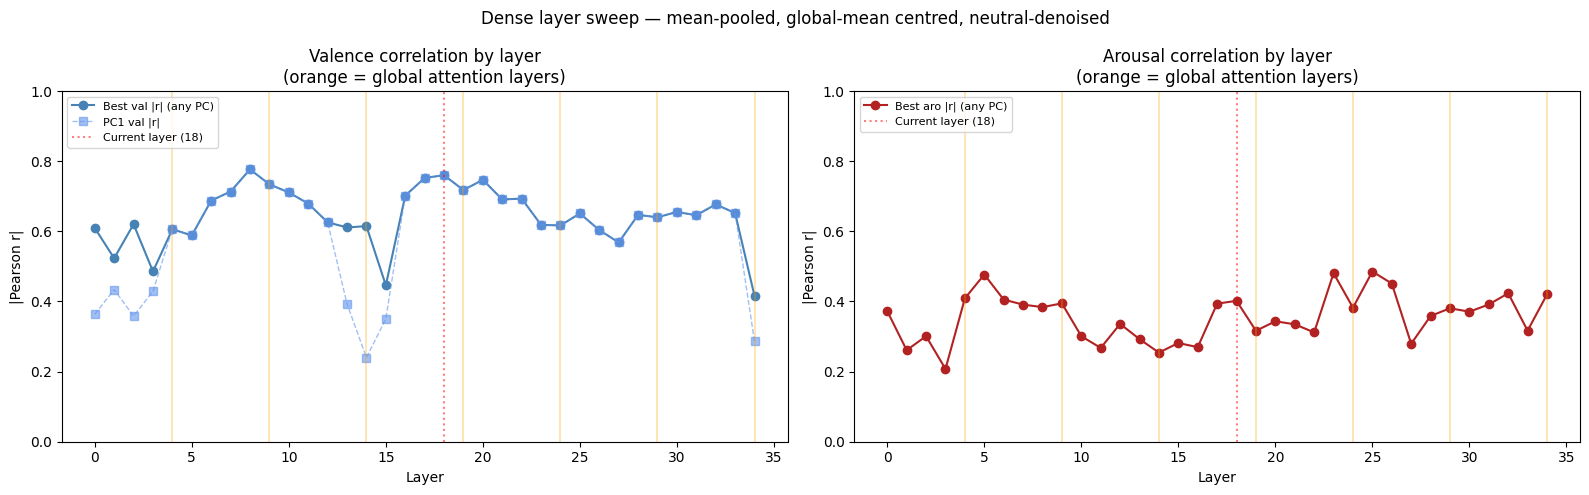

In [9]:
# ── Dense Layer Sweep ─────────────────────────────────────────────────────────
# Sweeps all 35 layers with global-mean centering + neutral PCA denoising.
# Shows where valence/arousal/dominance are best encoded.
#
# Key finding context:
#   Phase 1 (last-token): peak at layer 25
#   Phase 2 (mean-pool):  peak at layer 18
# The shift occurs because mean-pooling captures semantic content distributed
# across all token positions, so middle layers — where the signal has had
# time to build but isn't yet "summarised" for next-token prediction — dominate.

GLOBAL_LAYERS = [4, 9, 14, 19, 24, 29, 34]  # Gemma 4 E2B global attention layers

all_emotion_keys_sweep = [k for k in resid_acts.keys() if k != '__neutral__']
neutral_all = resid_acts['__neutral__']   # [100, n_layers, d_model]
n_lay = neutral_all.shape[1]

sweep_rows = []
for layer in range(n_lay):
    # Global-mean centred directions
    emot_means_l = np.stack([
        resid_acts[e][:, layer, :].mean(axis=0)
        for e in kept_names        # 171 emotions matched to NRC-VAD
    ])
    global_mean_l  = emot_means_l.mean(axis=0)
    dirs_l         = emot_means_l - global_mean_l

    # Neutral PCA denoising at this layer
    neutral_l   = neutral_all[:, layer, :]
    pca_n_l     = PCA()
    pca_n_l.fit(neutral_l)
    cumvar_n_l  = np.cumsum(pca_n_l.explained_variance_ratio_)
    n_pcs_l     = int(np.searchsorted(cumvar_n_l, VARIANCE_THRESHOLD) + 1)
    comps_l     = pca_n_l.components_[:n_pcs_l]
    dirs_den_l  = np.array([denoise_vec(d, comps_l) for d in dirs_l])

    # PCA on denoised directions
    n_comp = min(10, len(dirs_den_l) - 1)
    pca_l  = PCA(n_components=n_comp)
    sc_l   = pca_l.fit_transform(dirs_den_l)

    # PC1 correlations
    rv1, _ = stats.pearsonr(sc_l[:, 0], vad[:, 0])
    ra1, _ = stats.pearsonr(sc_l[:, 0], vad[:, 1])
    rd1, _ = stats.pearsonr(sc_l[:, 0], vad[:, 2])

    # Best PC for each VAD dimension (by |r|)
    def best_pc_r(dim_idx):
        rs = [abs(stats.pearsonr(sc_l[:, i], vad[:, dim_idx])[0]) for i in range(n_comp)]
        idx = int(np.argmax(rs))
        return idx + 1, rs[idx]

    bv_pc, bv_r = best_pc_r(0)
    ba_pc, ba_r = best_pc_r(1)

    sweep_rows.append(dict(
        layer=layer,
        ltype='GLOBAL' if layer in GLOBAL_LAYERS else 'local',
        pc1_var=pca_l.explained_variance_ratio_[0],
        pc1_val=rv1,
        pc1_aro=ra1,
        pc1_dom=rd1,
        best_val_pc=bv_pc, best_val_r=bv_r,
        best_aro_pc=ba_pc, best_aro_r=ba_r,
        n_neutral_pcs=n_pcs_l,
    ))

df_sweep = pd.DataFrame(sweep_rows)

# ── Print table ────────────────────────────────────────────────────────────────
print(f"{'Lay':>4}  {'type':>6}  {'PC1var%':>7}  "
      f"{'PC1 val_r':>10}  {'PC1 aro_r':>10}  "
      f"{'BestVal':>9}  {'BestAro':>9}  {'nNPCs':>5}")
for _, r in df_sweep.iterrows():
    marker = " ◄" if r.layer == LAYER else ""
    print(f"{int(r.layer):>4}  {r.ltype:>6}  {r.pc1_var*100:>6.1f}%  "
          f"{r.pc1_val:>+10.3f}  {r.pc1_aro:>+10.3f}  "
          f"PC{int(r.best_val_pc)} r={r.best_val_r:.3f}  "
          f"PC{int(r.best_aro_pc)} r={r.best_aro_r:.3f}  "
          f"{int(r.n_neutral_pcs):>5}{marker}")

# ── Report optimal layers ──────────────────────────────────────────────────────
best_val_idx = df_sweep['best_val_r'].idxmax()
best_aro_idx = df_sweep['best_aro_r'].idxmax()
print(f"\nBest valence layer: {int(df_sweep.loc[best_val_idx,'layer'])}  "
      f"PC{int(df_sweep.loc[best_val_idx,'best_val_pc'])} "
      f"r={df_sweep.loc[best_val_idx,'best_val_r']:.3f}")
print(f"Best arousal layer: {int(df_sweep.loc[best_aro_idx,'layer'])}  "
      f"PC{int(df_sweep.loc[best_aro_idx,'best_aro_pc'])} "
      f"r={df_sweep.loc[best_aro_idx,'best_aro_r']:.3f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(df_sweep['layer'], df_sweep['best_val_r'], 'o-', color='steelblue',
        label='Best val |r| (any PC)', linewidth=1.5)
ax.plot(df_sweep['layer'], df_sweep['pc1_val'].abs(), 's--', color='cornflowerblue',
        alpha=0.6, label='PC1 val |r|', linewidth=1)
for gl in GLOBAL_LAYERS:
    ax.axvline(gl, color='orange', alpha=0.35, linewidth=1.2)
ax.axvline(LAYER, color='red', alpha=0.5, linewidth=1.5, linestyle=':', label=f'Current layer ({LAYER})')
ax.set_xlabel('Layer'); ax.set_ylabel('|Pearson r|')
ax.set_title('Valence correlation by layer\n(orange = global attention layers)')
ax.legend(fontsize=8); ax.set_ylim(0, 1)

ax = axes[1]
ax.plot(df_sweep['layer'], df_sweep['best_aro_r'], 'o-', color='firebrick',
        label='Best aro |r| (any PC)', linewidth=1.5)
for gl in GLOBAL_LAYERS:
    ax.axvline(gl, color='orange', alpha=0.35, linewidth=1.2)
ax.axvline(LAYER, color='red', alpha=0.5, linewidth=1.5, linestyle=':', label=f'Current layer ({LAYER})')
ax.set_xlabel('Layer'); ax.set_ylabel('|Pearson r|')
ax.set_title('Arousal correlation by layer\n(orange = global attention layers)')
ax.legend(fontsize=8); ax.set_ylim(0, 1)

plt.suptitle('Dense layer sweep — mean-pooled, global-mean centred, neutral-denoised',
             fontsize=12)
plt.tight_layout()
plt.savefig('layer_sweep.png', dpi=150)
plt.show()


In [10]:
# ── Cell 7: Cumulative R² — which dimension is best explained? ───────────────
print(f"\n{'k':>4}  {'Valence R²':>11}  {'Arousal R²':>11}  {'Dominance R²':>13}  {'best':>8}")
for k in [1, 2, 3, 4, 5, 8, 10, 15, 20]:
    r2s = [
        sum(stats.pearsonr(scores[:, i], vad[:, j])[0]**2 for i in range(k))
        for j in range(3)
    ]
    best = dim_names[np.argmax(r2s)]
    print(f"{k:>4}  {r2s[0]:>11.3f}  {r2s[1]:>11.3f}  {r2s[2]:>13.3f}  {best:>8}")



   k   Valence R²   Arousal R²   Dominance R²      best
   1        0.578        0.034          0.350   valence
   2        0.581        0.117          0.391   valence
   3        0.582        0.279          0.459   valence
   4        0.637        0.391          0.527   valence
   5        0.640        0.391          0.527   valence
   8        0.671        0.443          0.557   valence
  10        0.676        0.476          0.581   valence
  15        0.696        0.509          0.663   valence
  20        0.733        0.544          0.680   valence


In [11]:
# ── Cell 8: What emotions drive each PC? ────────────────────────────────────
N_TOP = 6
for i in range(6):
    s = scores[:, i]
    pos = np.argsort(s)[-N_TOP:][::-1]
    neg = np.argsort(s)[:N_TOP]
    r_v, _ = stats.pearsonr(s, vad[:, 0])
    r_a, _ = stats.pearsonr(s, vad[:, 1])
    r_d, _ = stats.pearsonr(s, vad[:, 2])
    print(f"\nPC{i+1}  ({pca.explained_variance_ratio_[i]*100:.1f}% var)  "
          f"V={r_v:+.3f}  A={r_a:+.3f}  D={r_d:+.3f}")
    print(f"  +: {', '.join(kept_names[j] for j in pos)}")
    print(f"  −: {', '.join(kept_names[j] for j in neg)}")


PC1  (14.6% var)  V=+0.760  A=-0.184  D=+0.592
  +: happy, pleased, grateful, content, loving, triumphant
  −: hysterical, panicked, overwhelmed, tormented, dependent, sorry

PC2  (7.4% var)  V=-0.055  A=-0.288  D=-0.202
  +: relaxed, docile, empathetic, grateful, lonely, blissful
  −: offended, outraged, joyful, indifferent, frustrated, fulfilled

PC3  (5.6% var)  V=+0.033  A=-0.402  D=-0.260
  +: at_ease, relaxed, shocked, relieved, lazy, surprised
  −: obstinate, excited, greedy, vengeful, valiant, grief_stricken

PC4  (5.0% var)  V=+0.234  A=+0.335  D=+0.262
  +: enthusiastic, aroused, happy, vigilant, relaxed, ecstatic
  −: stubborn, gloomy, offended, bitter, ethical_conflict_distress, serene

PC5  (4.5% var)  V=-0.054  A=-0.013  D=-0.006
  +: calm, happy, annoyed, grumpy, cheerful, humiliated
  −: heartbroken, gloomy, vulnerable, aroused, inspired, patient

PC6  (3.9% var)  V=+0.088  A=-0.040  D=+0.158
  +: relieved, thrilled, panicked, defiant, safe, inspired
  −: jealous, elat

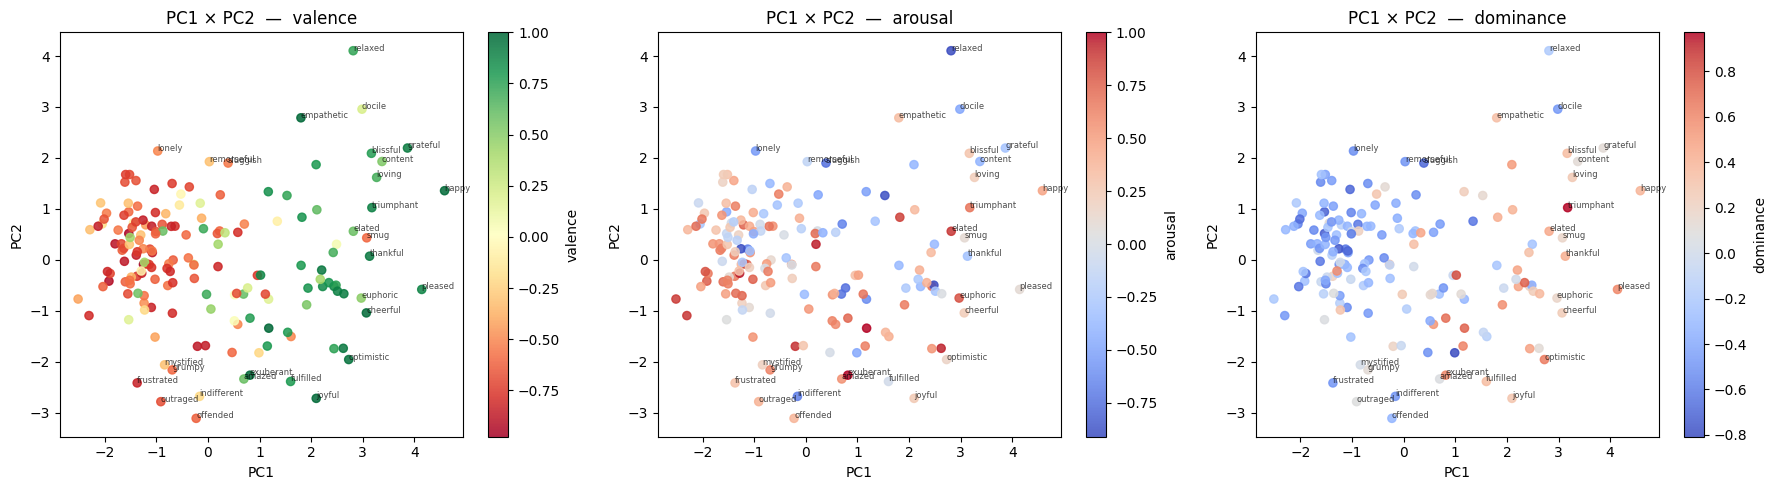

In [12]:
# ── Cell 9: Scatter plots — PC1×PC2 coloured by V, A, D ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (j, dim) in zip(axes, enumerate(dim_names)):
    sc = ax.scatter(scores[:, 0], scores[:, 1],
                    c=vad[:, j], cmap='RdYlGn' if dim == 'valence' else 'coolwarm',
                    s=35, alpha=0.85)
    plt.colorbar(sc, ax=ax, label=dim)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'PC1 × PC2  —  {dim}')
    thresh = 1.6 * scores[:, :2].std(axis=0)
    for name, s_row in zip(kept_names, scores):
        if abs(s_row[0]) > thresh[0] or abs(s_row[1]) > thresh[1]:
            ax.annotate(name, (s_row[0], s_row[1]), fontsize=6, alpha=0.7)
plt.tight_layout()
plt.savefig('pc1pc2_vad.png', dpi=150)
plt.show()

In [13]:
# ── Cell 10: Compute per-emotion power scores ─────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

norms = np.linalg.norm(dirs_denoised, axis=1)                    # [N]
valence_extremity = np.abs(vad[:, 0] - 0.5)            # [N]  NRC valence is 0–1, neutral at 0.5

cos_matrix = cosine_similarity(dirs_denoised)                     # [N, N]
np.fill_diagonal(cos_matrix, -1)                         # ignore self
max_cosine = cos_matrix.max(axis=1)                      # [N] — nearest neighbour similarity

power = norms * valence_extremity * (1.0 / (max_cosine + 1e-6))

# Summary: what drives power?
for name, n, v, mc, p in sorted(
        zip(kept_names, norms, valence_extremity, max_cosine, power),
        key=lambda x: -x[4])[:20]:
    print(f"{name:<30}  norm={n:.2f}  |v-0.5|={v:.3f}  max_cos={mc:.3f}  power={p:.2f}")


heartbroken                     norm=5.92  |v-0.5|=1.336  max_cos=0.388  power=20.39
uneasy                          norm=4.02  |v-0.5|=1.270  max_cos=0.308  power=16.60
grief_stricken                  norm=4.90  |v-0.5|=1.360  max_cos=0.415  power=16.06
impatient                       norm=5.55  |v-0.5|=1.000  max_cos=0.351  power=15.80
scornful                        norm=4.70  |v-0.5|=1.154  max_cos=0.346  power=15.67
afraid                          norm=3.74  |v-0.5|=1.477  max_cos=0.367  power=15.07
vulnerable                      norm=5.52  |v-0.5|=1.104  max_cos=0.427  power=14.30
offended                        norm=6.15  |v-0.5|=1.124  max_cos=0.486  power=14.22
humiliated                      norm=4.50  |v-0.5|=1.292  max_cos=0.419  power=13.86
furious                         norm=4.63  |v-0.5|=1.376  max_cos=0.465  power=13.69
bored                           norm=3.78  |v-0.5|=1.194  max_cos=0.333  power=13.53
annoyed                         norm=3.92  |v-0.5|=1.292  max_cos

In [14]:
# ── Cell 11: Select top-N per valence pole ────────────────────────────────────
def select_emotional_range(kept_names, dirs, vad, power, n_per_pole=15):
    pos_mask = vad[:, 0] > 0.5   # positive valence
    neg_mask = vad[:, 0] < 0.5   # negative valence

    def top_n(mask, n):
        idx = np.where(mask)[0]
        ranked = sorted(idx, key=lambda i: -power[i])
        return ranked[:n]

    pos_idx = top_n(pos_mask, n_per_pole)
    neg_idx = top_n(neg_mask, n_per_pole)
    selected = pos_idx + neg_idx

    print(f"\nPositive pole ({n_per_pole}):")
    for i in pos_idx:
        print(f"  {kept_names[i]:<30}  valence={vad[i,0]:.3f}  power={power[i]:.2f}")
    print(f"\nNegative pole ({n_per_pole}):")
    for i in neg_idx:
        print(f"  {kept_names[i]:<30}  valence={vad[i,0]:.3f}  power={power[i]:.2f}")

    return selected

selected_idx = select_emotional_range(kept_names, dirs_denoised, vad, power, n_per_pole=15)


Positive pole (15):
  happy                           valence=0.985  power=6.47
  cheerful                        valence=0.990  power=5.38
  joyful                          valence=0.990  power=5.16
  inspired                        valence=0.934  power=4.82
  empathetic                      valence=1.000  power=4.61
  fulfilled                       valence=0.792  power=4.61
  exuberant                       valence=1.000  power=4.21
  enthusiastic                    valence=0.770  power=4.20
  pleased                         valence=0.878  power=4.08
  thankful                        valence=0.938  power=4.04
  optimistic                      valence=0.958  power=3.96
  proud                           valence=0.812  power=3.89
  delighted                       valence=0.938  power=3.81
  invigorated                     valence=1.000  power=3.73
  satisfied                       valence=0.918  power=3.72

Negative pole (15):
  heartbroken                     valence=-0.836  power=20

In [15]:
# ── Cell 12: PCA and VAD correlations on emotional range subset ───────────────
def range_pca_analysis(selected_idx, n_pcs=10, label=""):
    sel_dirs = dirs_denoised[selected_idx]
    sel_vad  = vad[selected_idx]
    sel_names = [kept_names[i] for i in selected_idx]
    N_sel = len(selected_idx)

    pca_r = PCA(n_components=min(n_pcs, N_sel))
    scores_r = pca_r.fit_transform(sel_dirs)

    print(f"\n── {label} (N={N_sel}) ──")
    print(f"{'PC':>4}  {'var%':>6}  {'valence_r':>10}  {'arousal_r':>10}  {'dominance_r':>12}")
    for i in range(min(n_pcs, N_sel)):
        rv, _ = stats.pearsonr(scores_r[:, i], sel_vad[:, 0])
        ra, _ = stats.pearsonr(scores_r[:, i], sel_vad[:, 1])
        rd, _ = stats.pearsonr(scores_r[:, i], sel_vad[:, 2])
        print(f"{i+1:>4}  {pca_r.explained_variance_ratio_[i]*100:>5.1f}%"
              f"  {rv:>+10.3f}  {ra:>+10.3f}  {rd:>+12.3f}")

    # Cumulative R² for valence
    cum_r2_v = sum(stats.pearsonr(scores_r[:, i], sel_vad[:, 0])[0]**2
                   for i in range(min(5, N_sel)))
    print(f"\n  Valence R² (top-5 PCs combined): {cum_r2_v:.3f}  → r={cum_r2_v**0.5:.3f}")
    return pca_r, scores_r, sel_names

# Try different N values
for n in [10, 15, 20]:
    idx = select_emotional_range(kept_names, dirs_denoised, vad, power, n_per_pole=n)
    range_pca_analysis(idx, label=f"Top-{n} per pole")


Positive pole (10):
  happy                           valence=0.985  power=6.47
  cheerful                        valence=0.990  power=5.38
  joyful                          valence=0.990  power=5.16
  inspired                        valence=0.934  power=4.82
  empathetic                      valence=1.000  power=4.61
  fulfilled                       valence=0.792  power=4.61
  exuberant                       valence=1.000  power=4.21
  enthusiastic                    valence=0.770  power=4.20
  pleased                         valence=0.878  power=4.08
  thankful                        valence=0.938  power=4.04

Negative pole (10):
  heartbroken                     valence=-0.836  power=20.39
  uneasy                          valence=-0.770  power=16.60
  grief_stricken                  valence=-0.860  power=16.06
  impatient                       valence=-0.500  power=15.80
  scornful                        valence=-0.654  power=15.67
  afraid                          valence=-0.977

In [16]:
# ── Tri-polar selection ───────────────────────────────────────────────────────
# Requires: kept_names, dirs, vad, norms, max_cosine (all from Cells 3-10)
# NRC-VAD valence is in [-1, 1]; neutral ≈ 0

def select_tri_polar_emotions(kept_names, dirs, vad, norms, max_cosine,
                               n_per_pole=10, neutral_band=0.25):
    """
    Positive/negative poles: existing power score (consistent with Cell 10/11).
    Neutral pole: norm × distinctiveness, filtered to |valence| < neutral_band.
    """
    valence_extremity = np.abs(vad[:, 0] - 0.5)  # same formula as Cell 10
    power_full = norms * valence_extremity * (1.0 / (max_cosine + 1e-6))
    neutral_power = norms * (1.0 / (max_cosine + 1e-6))  # no valence term

    pos_idx = np.where(vad[:, 0] > 0.5)[0]
    pos_idx = pos_idx[np.argsort(-power_full[pos_idx])][:n_per_pole]

    neg_idx = np.where(vad[:, 0] < -0.5)[0]  # symmetric: clearly negative
    neg_idx = neg_idx[np.argsort(-power_full[neg_idx])][:n_per_pole]

    neutral_idx = np.where(np.abs(vad[:, 0]) < neutral_band)[0]
    neutral_idx = neutral_idx[np.argsort(-neutral_power[neutral_idx])][:n_per_pole]

    print(f"\nPositive pole ({len(pos_idx)}):")
    for i in pos_idx:
        print(f"  {kept_names[i]:<30}  v={vad[i,0]:+.3f}  power={power_full[i]:.2f}")
    print(f"\nNeutral pole ({len(neutral_idx)}, |v|<{neutral_band}):")
    for i in neutral_idx:
        print(f"  {kept_names[i]:<30}  v={vad[i,0]:+.3f}  neutral_power={neutral_power[i]:.2f}")
    print(f"\nNegative pole ({len(neg_idx)}):")
    for i in neg_idx:
        print(f"  {kept_names[i]:<30}  v={vad[i,0]:+.3f}  power={power_full[i]:.2f}")

    return {'positive': pos_idx.tolist(), 'neutral': neutral_idx.tolist(),
            'negative': neg_idx.tolist()}


def run_tripolar_pca(selected, kept_names, dirs, vad, n_pcs=5):
    pole_names = ['positive', 'neutral', 'negative']
    colours = {'positive': 'steelblue', 'negative': 'firebrick', 'neutral': 'goldenrod'}
    markers  = {'positive': '^', 'negative': 'v', 'neutral': 'o'}

    all_idx = selected['positive'] + selected['neutral'] + selected['negative']
    labels  = (
        ['positive'] * len(selected['positive']) +
        ['neutral']  * len(selected['neutral']) +
        ['negative'] * len(selected['negative'])
    )
    sel_dirs  = dirs[all_idx]
    sel_vad   = vad[all_idx]
    sel_names = [kept_names[i] for i in all_idx]

    pca_t    = PCA(n_components=min(n_pcs, len(all_idx)))
    scores_t = pca_t.fit_transform(sel_dirs)

    print(f"\n── Tri-polar PCA (N={len(all_idx)}) ──")
    print(f"{'PC':>4}  {'var%':>6}  {'valence_r':>10}  {'arousal_r':>10}  {'dominance_r':>12}")
    for i in range(pca_t.n_components_):
        rv, _ = stats.pearsonr(scores_t[:, i], sel_vad[:, 0])
        ra, _ = stats.pearsonr(scores_t[:, i], sel_vad[:, 1])
        rd, _ = stats.pearsonr(scores_t[:, i], sel_vad[:, 2])
        print(f"{i+1:>4}  {pca_t.explained_variance_ratio_[i]*100:>5.1f}%"
              f"  {rv:>+10.3f}  {ra:>+10.3f}  {rd:>+12.3f}")

    # PC1×PC2 and PC2×PC3 — shape = pole, colour = arousal
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    arousals = sel_vad[:, 1]
    for ax, (xpc, ypc) in zip(axes, [(0, 1), (1, 2)]):
        for pole in pole_names:
            idx = [i for i, l in enumerate(labels) if l == pole]
            sc = ax.scatter(
                scores_t[idx, xpc], scores_t[idx, ypc],
                c=arousals[idx], cmap='RdYlBu_r', vmin=-1, vmax=1,
                marker=markers[pole], s=90, edgecolors=colours[pole],
                linewidths=1.5, label=pole, zorder=3,
            )
            for i in idx:
                ax.annotate(sel_names[i], (scores_t[i, xpc], scores_t[i, ypc]),
                            fontsize=7, alpha=0.75, ha='center', va='bottom')
        plt.colorbar(sc, ax=ax, label='Arousal')
        ax.set_xlabel(f'PC{xpc+1}'); ax.set_ylabel(f'PC{ypc+1}')
        ax.legend()
    axes[0].set_title('PC1 vs PC2 — shape=pole, colour=arousal')
    axes[1].set_title('PC2 vs PC3 — shape=pole, colour=arousal')
    plt.suptitle(f'Tri-polar emotional range — n={len(selected["positive"])} per pole', fontsize=12)
    plt.tight_layout()
    plt.savefig('tripolar_pca.png', dpi=150)
    plt.show()
    return scores_t, pca_t


Neutral band coverage (valence in [-1,1], neutral=0):
  |v|<0.15:   8 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)
  |v|<0.20:  12 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)
  |v|<0.25:  18 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)
  |v|<0.30:  20 emotions — astonished(+0.02), alert(-0.04), eager(+0.04), vigilant(-0.06), at_ease(+0.06), nostalgic(-0.08)

============================================================  n_per_pole=8

Positive pole (8):
  happy                           v=+0.985  power=6.47
  cheerful                        v=+0.990  power=5.38
  joyful                          v=+0.990  power=5.16
  inspired                        v=+0.934  power=4.82
  empathetic                      v=+1.000  power=4.61
  fulfilled                       v=+0.792  power=4.61
  exuberant             

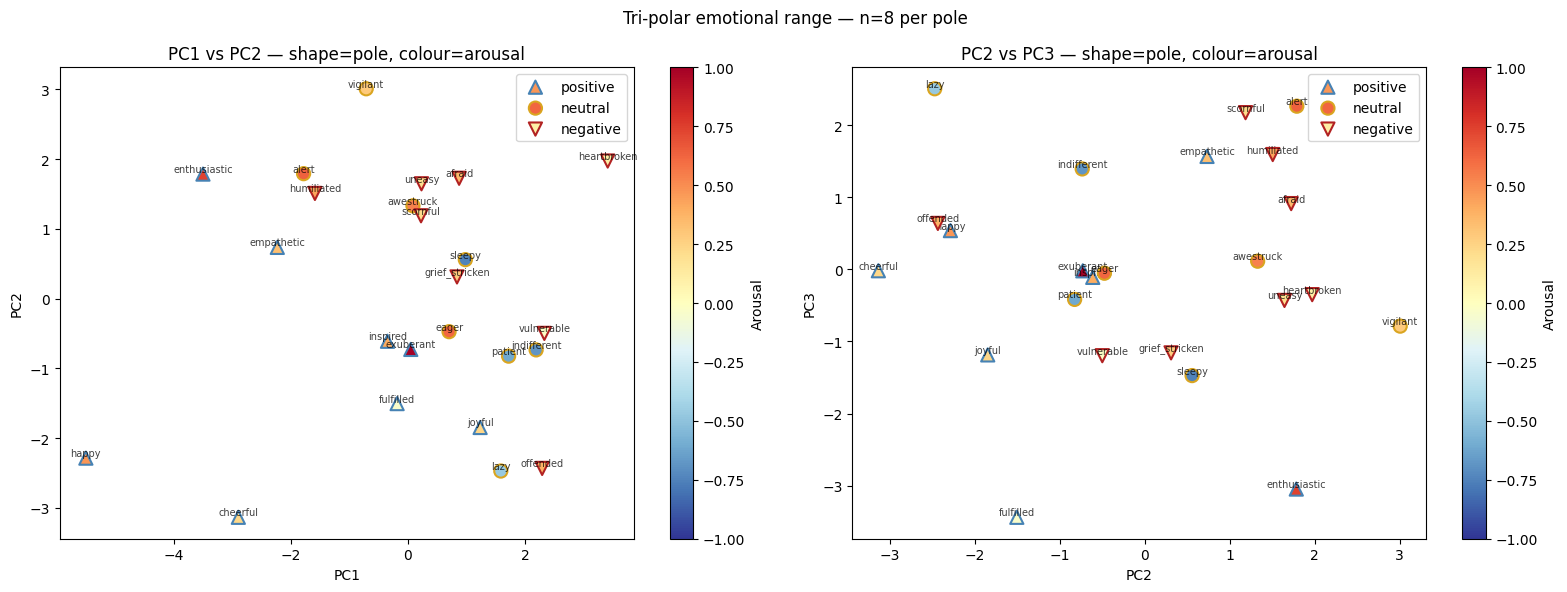


============================================================  n_per_pole=10

Positive pole (10):
  happy                           v=+0.985  power=6.47
  cheerful                        v=+0.990  power=5.38
  joyful                          v=+0.990  power=5.16
  inspired                        v=+0.934  power=4.82
  empathetic                      v=+1.000  power=4.61
  fulfilled                       v=+0.792  power=4.61
  exuberant                       v=+1.000  power=4.21
  enthusiastic                    v=+0.770  power=4.20
  pleased                         v=+0.878  power=4.08
  thankful                        v=+0.938  power=4.04

Neutral pole (10, |v|<0.25):
  eager                           v=+0.042  neutral_power=12.42
  awestruck                       v=+0.230  neutral_power=12.11
  lazy                            v=-0.216  neutral_power=11.95
  indifferent                     v=-0.208  neutral_power=11.63
  sleepy                          v=+0.208  neutral_power=11.50
  

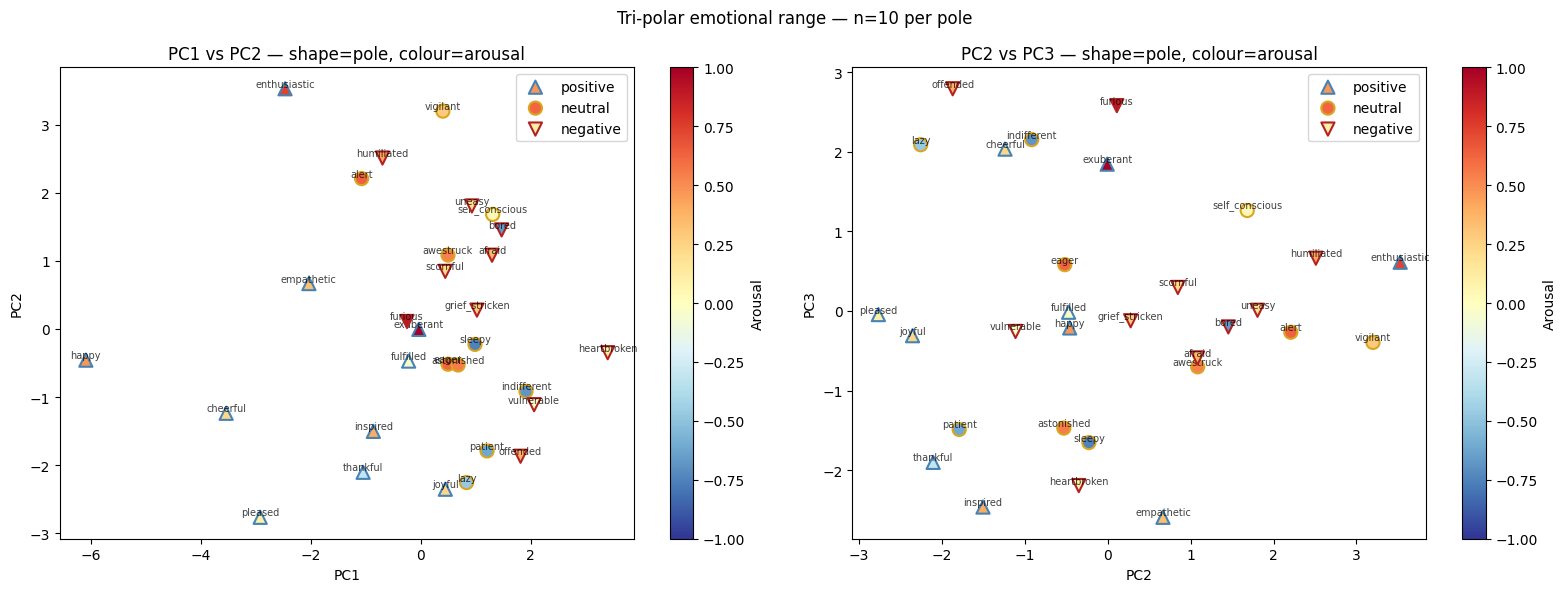


============================================================  n_per_pole=12

Positive pole (12):
  happy                           v=+0.985  power=6.47
  cheerful                        v=+0.990  power=5.38
  joyful                          v=+0.990  power=5.16
  inspired                        v=+0.934  power=4.82
  empathetic                      v=+1.000  power=4.61
  fulfilled                       v=+0.792  power=4.61
  exuberant                       v=+1.000  power=4.21
  enthusiastic                    v=+0.770  power=4.20
  pleased                         v=+0.878  power=4.08
  thankful                        v=+0.938  power=4.04
  optimistic                      v=+0.958  power=3.96
  proud                           v=+0.812  power=3.89

Neutral pole (12, |v|<0.25):
  eager                           v=+0.042  neutral_power=12.42
  awestruck                       v=+0.230  neutral_power=12.11
  lazy                            v=-0.216  neutral_power=11.95
  indifferent       

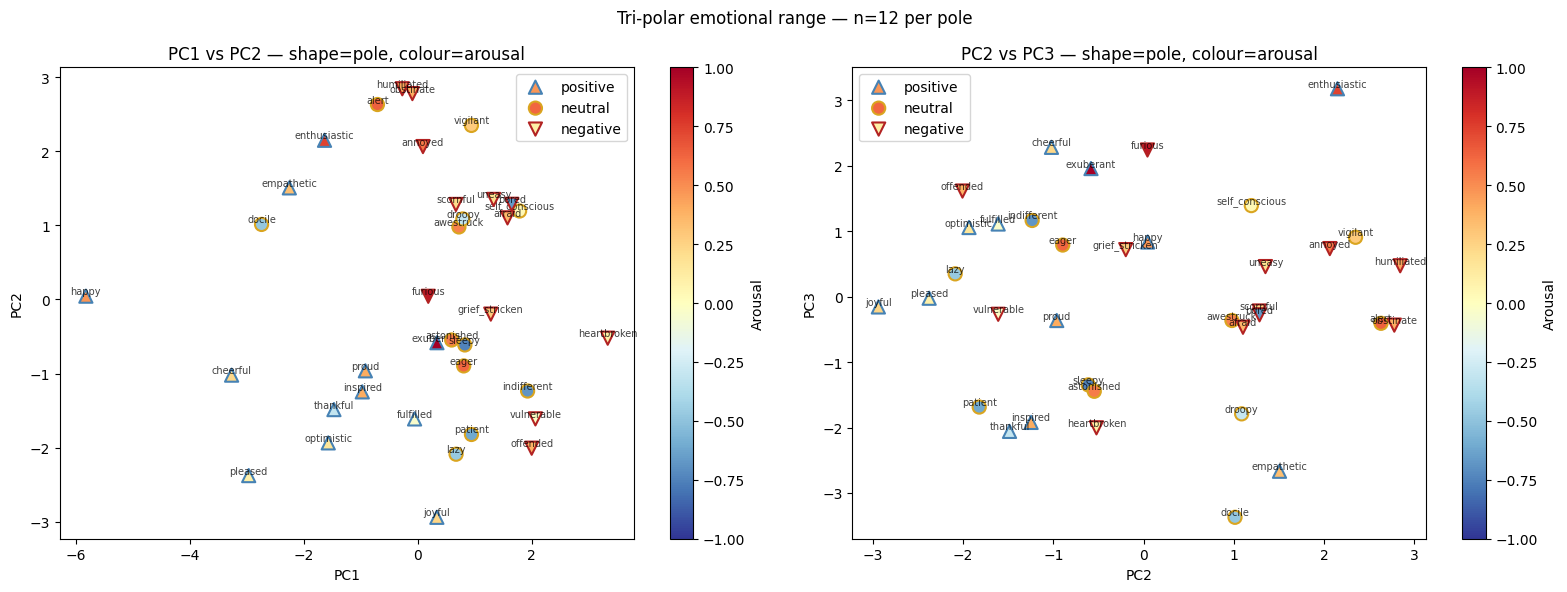

In [17]:
# ── Exercise ──────────────────────────────────────────────────────────────────

# First: check how many emotions fall in the neutral band at each threshold
print("Neutral band coverage (valence in [-1,1], neutral=0):")
for band in [0.15, 0.20, 0.25, 0.30]:
    in_band = [(kept_names[i], vad[i, 0]) for i in range(len(kept_names))
               if abs(vad[i, 0]) < band]
    preview = ', '.join(f"{n}({v:+.2f})" for n, v in
                        sorted(in_band, key=lambda x: abs(x[1]))[:6])
    print(f"  |v|<{band:.2f}: {len(in_band):3d} emotions — {preview}")

# Run at a few N values
for n in [8, 10, 12]:
    print(f"\n{'='*60}  n_per_pole={n}")
    selected = select_tri_polar_emotions(
        kept_names, dirs_denoised, vad, norms, max_cosine,
        n_per_pole=n, neutral_band=0.25,
    )
    run_tripolar_pca(selected, kept_names, dirs_denoised, vad)